#  Satellite Image Colorization Using U-Net

## Project Description

This project aims to **colorize grayscale satellite images** using a deep learning approach. Specifically, we employ a **U-Net architecture**—a popular encoder-decoder convolutional neural network originally designed for biomedical image segmentation. The model takes in grayscale satellite images and learns to output realistic RGB colorized versions.

The dataset used is the **EuroSAT** dataset, which contains both color and grayscale satellite images across various land-use classes such as Forest, River, Industrial, and more.

---

##  Contributors

- **Prateek Vashishth** — `BT22CSE224`  
- **Kamal Chandra** — `BT22CSE223`  
- **Harsh Agarwal** — `BT22CSE228`  

---



### Importing Required Libraries

This cell imports all the essential libraries required for:

- Image preprocessing (`cv2`, `numpy`)
- Deep learning using **TensorFlow / Keras** (e.g., `Model`, `Conv2D`, `MaxPooling2D`, etc.)
- Dataset splitting (`train_test_split`)
- Optimizers and losses like `Adam` and `MeanSquaredError`

These are foundational components for model construction, training, and evaluation.


In [3]:
from tensorflow.keras.layers import MaxPooling2D, UpSampling2D, Concatenate
import numpy as np
import cv2
import tensorflow as tf
import os
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, Add
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError


### Defining Dataset Paths and Classes

This cell defines:
- The path to the **color EuroSAT dataset**
- The path to the **grayscale version**
- A list of 10 land-use **class names** (e.g., River, Forest, Industrial) used to navigate subfolders while loading data.


In [4]:
color_dataset_path = '/kaggle/input/eurosat/dataset/EuroSAT'  
gray_scale_dataset_path = '/kaggle/input/eurosat/dataset/EuroSAT_gray_scale'
class_folders = ['River', 'SeaLake', 'Residential', 'Pasture', 'AnnualCrop','Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'PermanentCrop']

### Data Loader Function

This function `load_data(...)`:
- Iterates through each class folder
- Loads both grayscale and color images
- Resizes them to a fixed shape (64x64)
- Normalizes pixel values to range [0, 1]
- Expands grayscale images from `(64,64)` to `(64,64,1)` for model compatibility

This prepares two datasets:  
`X` for input grayscale images and `Y` for target color images.


In [5]:
def load_data(color_dataset_path, gray_scale_dataset_path, class_folders, size=(64, 64)):
    X = []  # Grayscale images
    Y = []  # Color images

    for folder in class_folders:
        color_folder = os.path.join(color_dataset_path, folder)
        gray_folder = os.path.join(gray_scale_dataset_path, f"{folder}_gray_scale")

        if not os.path.exists(color_folder) or not os.path.exists(gray_folder):
            print(f"Skipping missing folder: {color_folder} or {gray_folder}")
            continue

        # Lists all files in the color and grayscale folder
        color_files = os.listdir(color_folder)
        gray_files = os.listdir(gray_folder)

        for filename in color_files:
            color_path = os.path.join(color_folder, filename)
            gray_path = os.path.join(gray_folder, filename)

            if not os.path.isfile(color_path) or not os.path.isfile(gray_path):
                print(f"Skipping missing files: {color_path} or {gray_path}")
                continue

            color_img = cv2.imread(color_path)
            gray_img = cv2.imread(gray_path, cv2.IMREAD_GRAYSCALE)

            if color_img is None or gray_img is None:
                print(f"Error loading images: {color_path} or {gray_path}")
                continue

            # Resizes images to the desired size
            color_img = cv2.resize(color_img, size)
            gray_img = cv2.resize(gray_img, size)

            # Expands dimensions of grayscale image to (height, width, 1)
            gray_img = np.expand_dims(gray_img, axis=-1)

            # Normalizes pixel values to [0, 1]
            X.append(gray_img / 255.0)
            Y.append(color_img / 255.0) 

    return np.array(X), np.array(Y)

### Building the U-Net Colorization Model

This cell defines a **U-Net architecture** tailored for image colorization:

- **Encoder**: Downsamples input to extract features (Conv → ReLU → MaxPool)
- **Bottleneck**: Deepest layer with high-level features
- **Decoder**: Upsamples and combines features from encoder (using `Concatenate`) to reconstruct RGB image

Final layer uses a `sigmoid` activation with 3 filters to output an RGB image in [0,1].

The model summary is also printed to show layer-wise details.


In [4]:
def build_colorization_model(input_shape):
    inputs = Input(shape=input_shape)

    # Encoder
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    # Bottleneck
    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(c4)

    # Decoder
    u5 = UpSampling2D((2, 2))(c4)
    u5 = Concatenate()([u5, c3])
    c5 = Conv2D(256, (3, 3), activation='relu', padding='same')(u5)
    c5 = Conv2D(256, (3, 3), activation='relu', padding='same')(c5)

    u6 = UpSampling2D((2, 2))(c5)
    u6 = Concatenate()([u6, c2])
    c6 = Conv2D(128, (3, 3), activation='relu', padding='same')(u6)
    c6 = Conv2D(128, (3, 3), activation='relu', padding='same')(c6)

    u7 = UpSampling2D((2, 2))(c6)
    u7 = Concatenate()([u7, c1])
    c7 = Conv2D(64, (3, 3), activation='relu', padding='same')(u7)
    c7 = Conv2D(64, (3, 3), activation='relu', padding='same')(c7)

    outputs = Conv2D(3, (1, 1), activation='sigmoid')(c7)  # 3 channels for RGB color

    model = Model(inputs=[inputs], outputs=[outputs])
    return model


model = build_colorization_model((64, 64, 1))  # Input is grayscale
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 8, 8, 256) │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 8, 8, 512) │  1,180,160 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 8, 8, 512) │  2,359,808 │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 768)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  1,769,728 │ concatenate[0][0] │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │    590,080 │ conv2d_8[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 32, 32,    │          0 │ conv2d_9[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 7,781,891 (29.69 MB)

 Trainable params: 7,781,891 (29.69 MB)

 Non-trainable params: 0 (0.00 B)

### Loading Data and Splitting for Validation

This cell:
- Calls `load_data()` to get `X` (grayscale) and `Y` (color)
- Splits the dataset into:
  - `X_train`, `Y_train` for training (80%)
  - `X_val`, `Y_val` for validation (20%)

Validation helps evaluate the model on unseen data during training.


In [6]:
X, Y = load_data(color_dataset_path, gray_scale_dataset_path, class_folders, size=(64, 64))


X_train, X_val = X[:int(0.8*len(X))], X[int(0.8*len(X)):]
Y_train, Y_val = Y[:int(0.8*len(Y))], Y[int(0.8*len(Y)):]

### Dataset Shapes

This cell prints the shapes of:
- `X` → grayscale input images
- `Y` → corresponding color images

It's a quick sanity check to confirm the data was loaded and processed correctly, with expected dimensions like:
- `X.shape = (N, 64, 64, 1)`
- `Y.shape = (N, 64, 64, 3)`


In [6]:
print(f"Shape of X (grayscale images): {X.shape}")
print(f"Shape of Y (color images): {Y.shape}")


Shape of X (grayscale images): (27000, 64, 64, 1)
Shape of Y (color images): (27000, 64, 64, 3)


### Checking an Individual Sample Shape

This cell checks the shape of the first grayscale image using `X[0].shape`.

Since the input to the model requires a 4D tensor, this should show a single image in `(64, 64, 1)` format.

In [7]:
X[0].shape

(64, 64, 1)

### Compiling the Model

This cell compiles the U-Net model using:
- **Adam optimizer**: An adaptive optimizer well-suited for deep learning.
- **Mean Squared Error (MSE)**: The loss function used for comparing the predicted color image with the ground truth.

MSE is appropriate for regression tasks like image colorization where we want pixel-wise similarity.


In [8]:
model.compile(
    optimizer=Adam(),
    loss=MeanSquaredError(),
)


### Training the Model and Saving Weights

This cell performs:
- Training for 50 epochs with batch size 16.
- Uses the training and validation sets defined earlier.
- **Model weights are saved** after training to `'colorization_model_weights.weights.h5'`.

The training is wrapped in a `try-except` block to catch any runtime issues.


In [9]:
# Training
try:
    history = model.fit(X_train, Y_train, batch_size=16, epochs=50, validation_data=(X_val, Y_val))

    # Model weights
    weights_path = 'colorization_model_weights.weights.h5'
    model.save_weights(weights_path)
    print(f"Model weights saved successfully to {weights_path}.")

except Exception as e:
    print(f"Error during training: {e}")

Epoch 1/50


I0000 00:00:1743513885.992826     104 service.cc:145] XLA service 0x78623c017810 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1743513885.992889     104 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1743513885.992893     104 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


   3/1350 ━━━━━━━━━━━━━━━━━━━━ 1:21 60ms/step - loss: 0.0358

I0000 00:00:1743513900.548991     104 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1350/1350 ━━━━━━━━━━━━━━━━━━━━ 94s 56ms/step - loss: 0.0060 - val_loss: 0.0014
Epoch 2/50
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 71s 53ms/step - loss: 0.0011 - val_loss: 0.0013
Epoch 3/50
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 70s 52ms/step - loss: 0.0011 - val_loss: 0.0013
Epoch 4/50
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 69s 51ms/step - loss: 9.9251e-04 - val_loss: 0.0016
Epoch 5/50
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 69s 51ms/step - loss: 9.3898e-04 - val_loss: 0.0012
Epoch 6/50
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 69s 51ms/step - loss: 8.9904e-04 - val_loss: 0.0012
Epoch 7/50
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 69s 51ms/step - loss: 8.8167e-04 - val_loss: 0.0011
Epoch 8/50
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 68s 50ms/step - loss: 8.5487e-04 - val_loss: 0.0013
Epoch 9/50
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 68s 51ms/step - loss: 8.3828e-04 - val_loss: 0.0012
Epoch 10/50
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 68s 51ms/step - loss: 8.1734e-04 - val_loss: 0.0011
Epoch 11/50
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 68s 51ms/step - loss: 8.1213e-04 - val_

### Model Evaluation using SSIM and PSNR

This cell defines a function `evaluate_model(...)` which computes:

- **SSIM (Structural Similarity Index)**: Measures perceptual similarity between original and predicted images.
- **PSNR (Peak Signal-to-Noise Ratio)**: Indicates how close the predicted image is to the original (higher = better).

The model is evaluated on each validation image, and average SSIM and PSNR scores are printed. These are crucial metrics for image generation tasks.


In [11]:
import numpy as np
import tensorflow as tf
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

def evaluate_model(model, X_val, Y_val, display_interval=10):
    total_ssim, total_psnr = 0, 0
    num_samples = len(X_val)

    print(f"Total images to process: {num_samples}")

    for i in range(num_samples):
        grayscale_image = np.expand_dims(X_val[i], axis=0)  # Add batch dim
        true_color_image = Y_val[i]

        # Get model prediction
        predicted_image = model.predict(grayscale_image, verbose=0)[0]
        min_dim = min(predicted_image.shape[:2])
        win_size = min(7, min_dim)

        #SSIM and PSNR
        ssim_value = ssim(true_color_image, predicted_image, data_range=1, win_size=win_size, channel_axis=-1)
        psnr_value = psnr(true_color_image, predicted_image, data_range=1)

        total_ssim += ssim_value
        total_psnr += psnr_value

        # Progress at intervals
        if (i + 1) % display_interval == 0 or (i + 1) == num_samples:
            print(f"Processed {i + 1}/{num_samples} images...")

    avg_ssim = total_ssim / num_samples
    avg_psnr = total_psnr / num_samples

    print(f"\nEvaluation Complete ✅")
    print(f"Average SSIM: {avg_ssim:.4f}")
    print(f"Average PSNR: {avg_psnr:.4f} dB")

evaluate_model(model, X_val, Y_val, display_interval=200)


Total images to process: 5400
Processed 200/5400 images...
Processed 400/5400 images...
Processed 600/5400 images...
Processed 800/5400 images...
Processed 1000/5400 images...
Processed 1200/5400 images...
Processed 1400/5400 images...
Processed 1600/5400 images...
Processed 1800/5400 images...
Processed 2000/5400 images...
Processed 2200/5400 images...
Processed 2400/5400 images...
Processed 2600/5400 images...
Processed 2800/5400 images...
Processed 3000/5400 images...
Processed 3200/5400 images...
Processed 3400/5400 images...
Processed 3600/5400 images...
Processed 3800/5400 images...
Processed 4000/5400 images...
Processed 4200/5400 images...
Processed 4400/5400 images...
Processed 4600/5400 images...
Processed 4800/5400 images...
Processed 5000/5400 images...
Processed 5200/5400 images...
Processed 5400/5400 images...

Evaluation Complete ✅
Average SSIM: 0.9760
Average PSNR: 31.4834 dB


### Pixel-by-Pixel Similarity Evaluation

This cell introduces a **custom evaluation metric**:  
 **Pixel-by-pixel similarity**, which compares each RGB pixel in the predicted image to its corresponding pixel in the ground truth image.

#### Key Components:
- `pixel_by_pixel_similarity(...)`:  
  - Flattens both the predicted and true RGB images.
  - Rounds pixel values and casts them to integers.
  - Computes accuracy using `sklearn.metrics.accuracy_score`.

- `evaluate_pixel_similarity(...)`:  
  - Iterates over the validation set.
  - Predicts the color image using the trained model.
  - Computes and accumulates pixel-wise similarity.
  - Displays progress at regular intervals (every 400 images).
  - Prints the **average similarity score** in percentage (%).

This metric gives intuitive feedback on how many individual pixels the model predicts correctly — a useful visual similarity proxy for colorization tasks.


In [16]:
import numpy as np
from sklearn.metrics import accuracy_score
import tensorflow as tf

def pixel_by_pixel_similarity(predicted_image, true_image):
    predicted_image = np.round(predicted_image).astype(int)  
    true_image = np.round(true_image).astype(int)  

    # Reshape to flatten the images
    predicted_image_flatten = predicted_image.flatten()
    true_image_flatten = true_image.flatten()

    # Compute the pixel-by-pixel accuracy
    accuracy = accuracy_score(true_image_flatten, predicted_image_flatten)
    
    return accuracy * 100 

def evaluate_pixel_similarity(model, X_val, Y_val, display_interval=100):
    total_similarity = 0
    total_images = len(X_val)
    
    print(f"Total images to process: {total_images}")

    # Loop through all validation images
    for i in range(total_images):
        grayscale_image = X_val[i:i+1] 
        true_color_image = Y_val[i] 
        predicted_image = model.predict(grayscale_image, verbose=0)[0]
        
        # Evaluate pixel-by-pixel similarity
        similarity = pixel_by_pixel_similarity(predicted_image, true_color_image)
        total_similarity += similarity

        # Progress at intervals
        if (i + 1) % display_interval == 0 or (i + 1) == total_images:
            print(f"Processed {i + 1}/{total_images} images")

    # Calculate average similarity across all images
    avg_similarity = total_similarity / total_images
    print(f"Average Pixel-by-Pixel Similarity: {avg_similarity:.2f}% ✅")

evaluate_pixel_similarity(model, X_val, Y_val, display_interval=400)


Total images to process: 5400
Processed 400/5400 images
Processed 800/5400 images
Processed 1200/5400 images
Processed 1600/5400 images
Processed 2000/5400 images
Processed 2400/5400 images
Processed 2800/5400 images
Processed 3200/5400 images
Processed 3600/5400 images
Processed 4000/5400 images
Processed 4400/5400 images
Processed 4800/5400 images
Processed 5200/5400 images
Processed 5400/5400 images
Average Pixel-by-Pixel Similarity: 95.38% ✅


### Visualizing Model Predictions

This cell defines a `test_model(...)` function that visualizes and compares:

1. **Grayscale Input** — the input image provided to the model  
2. **Predicted Color Image** — the colorized image generated by the model  
3. **True Color Image** — the original RGB image from the dataset

#### Key Steps:
- Expands grayscale input to match batch shape expected by the model.
- Predicts the color image using the trained U-Net model.
- Converts all images from `[0, 1]` range back to `[0, 255]` for proper display.
- Uses `matplotlib` to render a side-by-side visual comparison.

📷 This function helps qualitatively assess how well the model colorizes grayscale satellite images.


I0000 00:00:1743581267.305960     108 service.cc:145] XLA service 0x7df9d0003f10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1743581267.306014     108 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1743581267.306018     108 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


I0000 00:00:1743581272.493195     108 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


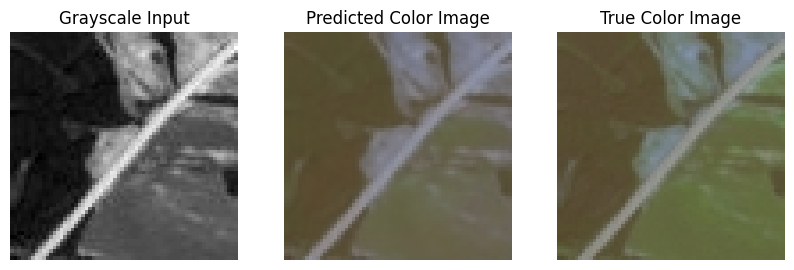

In [7]:
# Test function to visualize predictions
def test_model(model, X_val, Y_val, index=0):
    grayscale_img = X_val[index]
    true_color_img = Y_val[index]
    grayscale_img_batch = np.expand_dims(grayscale_img, axis=0)

    # Predict the colorized image
    predicted_color_img = model.predict(grayscale_img_batch)[0]  # Remove batch dimension after prediction

    # Rescale from [0, 1] to [0, 255] for display purposes
    predicted_color_img = (predicted_color_img * 255).astype(np.uint8)
    true_color_img = (true_color_img * 255).astype(np.uint8)
    grayscale_img = (grayscale_img.squeeze() * 255).astype(np.uint8)

    # Display images for comparison
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 3, 1)
    plt.title("Grayscale Input")
    plt.imshow(grayscale_img, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Predicted Color Image")
    plt.imshow(predicted_color_img)
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("True Color Image")
    plt.imshow(true_color_img)
    plt.axis('off')

    plt.show()


test_model(model, X_val, Y_val, index=1)

In [15]:
# Save the trained model
model.save("colorization_model.keras")
print("Model saved successfully...")


Model saved successfully...


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


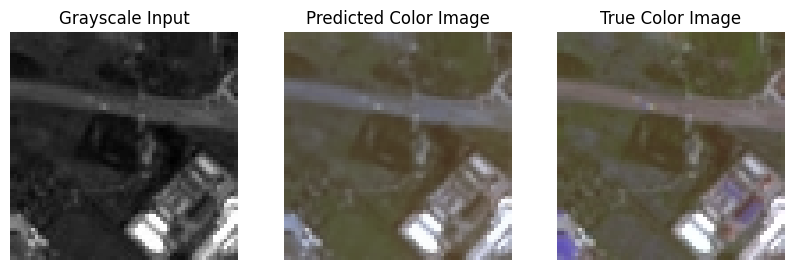

In [8]:
test_model(model, X_val, Y_val, index=2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


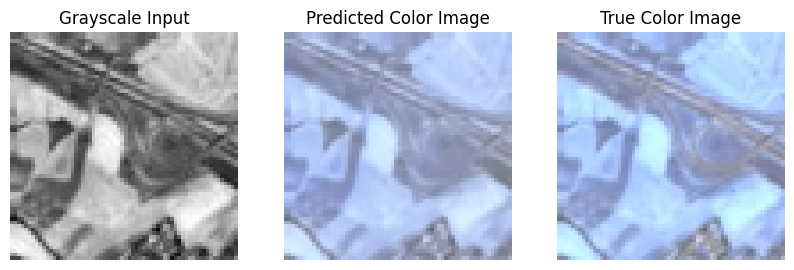

In [9]:
test_model(model, X_val, Y_val, index=3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


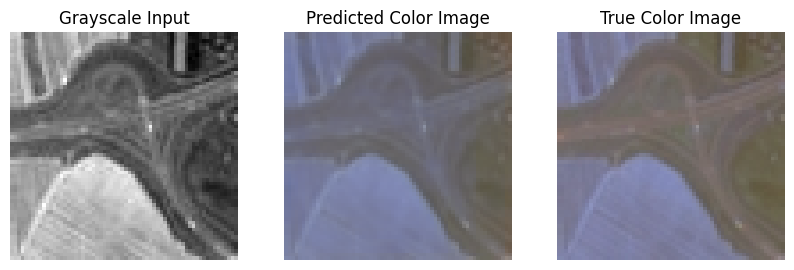

In [10]:
test_model(model, X_val, Y_val, index=4)